In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import requests
import folium
import time
from folium.plugins import MarkerCluster

sns.set_theme(style='whitegrid', context='notebook')


## EDA without tiers 

In [2]:
# pull data
df_schools = pd.read_csv('schools_data.csv')

# check for missing values and data types
print(df_schools.info()) # no missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182 entries, 0 to 181
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   school_name        182 non-null    object 
 1   address            182 non-null    object 
 2   postal_code        182 non-null    int64  
 3   nature_code        182 non-null    object 
 4   sap_ind            182 non-null    int64  
 5   autonomous_ind     182 non-null    int64  
 6   gifted_ind         182 non-null    int64  
 7   P1_demand          182 non-null    float64
 8   P2A_demand         182 non-null    float64
 9   P2B_demand         182 non-null    float64
 10  P2C_demand         182 non-null    float64
 11  P2CS_demand        182 non-null    float64
 12  subject_count      182 non-null    int64  
 13  distprog_count     182 non-null    int64  
 14  cca_clubs          182 non-null    int64  
 15  cca_others         182 non-null    int64  
 16  cca_sports         182 non

In [3]:
# columns for analysis
school_cols = ['school_name', 'address', 'postal_code']
numeric_cols = [c for c in df_schools.select_dtypes(include=[np.number]).columns if c not in school_cols] # for histograms and correlation
categorical_cols = ['nature_code'] # for bar charts

# Summary statistics
display(df_schools[numeric_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
sap_ind,182.0,0.082418,0.275758,0.00,0.0000,0.000,0.0000,1.00
autonomous_ind,182.0,0.016484,0.127677,0.00,0.0000,0.000,0.0000,1.00
gifted_ind,182.0,0.049451,0.217405,0.00,0.0000,0.000,0.0000,1.00
P1_demand,182.0,0.465220,0.125296,0.00,0.3725,0.495,0.5600,0.73
P2A_demand,182.0,0.539066,0.465095,0.04,0.1725,0.330,0.8175,2.65
P2B_demand,182.0,0.463462,0.673798,0.00,0.0100,0.060,0.7250,2.70
P2C_demand,182.0,1.053462,0.858081,0.08,0.3800,0.890,1.4875,5.75
P2CS_demand,182.0,0.416429,0.594576,0.00,0.0000,0.215,0.6700,5.29
subject_count,182.0,26.791209,5.481292,12.00,24.0000,29.000,29.0000,52.00
distprog_count,182.0,2.032967,0.491936,0.00,2.0000,2.000,2.0000,6.00


Text(0.5, 1.0, 'Correlation between School Features')

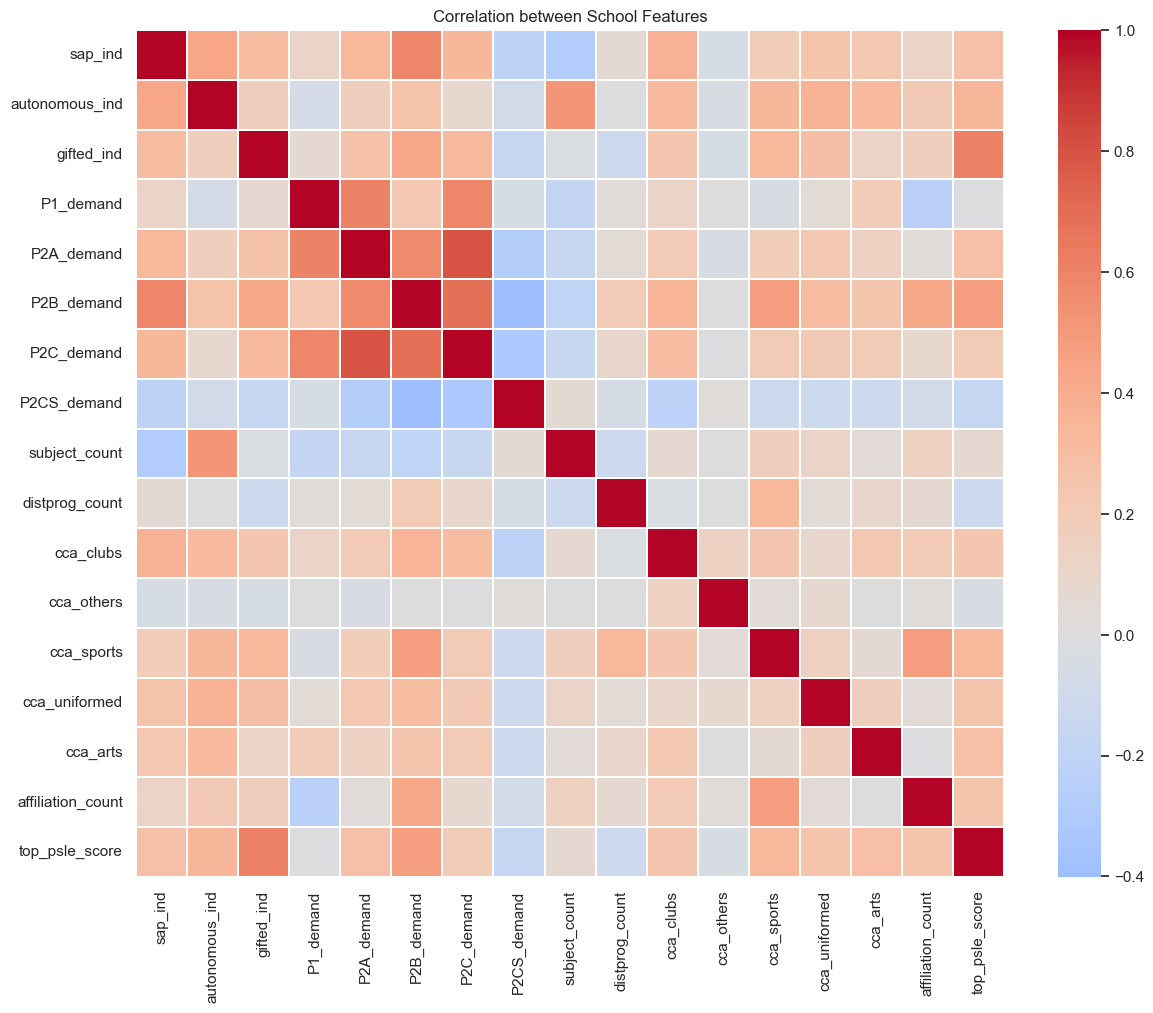

In [4]:
corr = df_schools[numeric_cols].corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.3)
plt.title("Correlation between School Features")

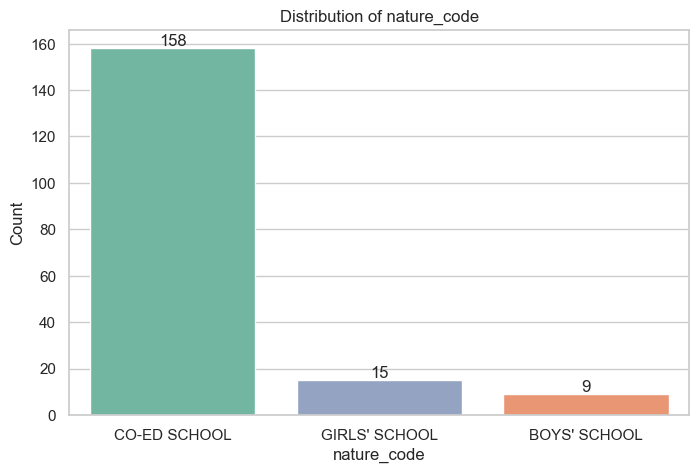

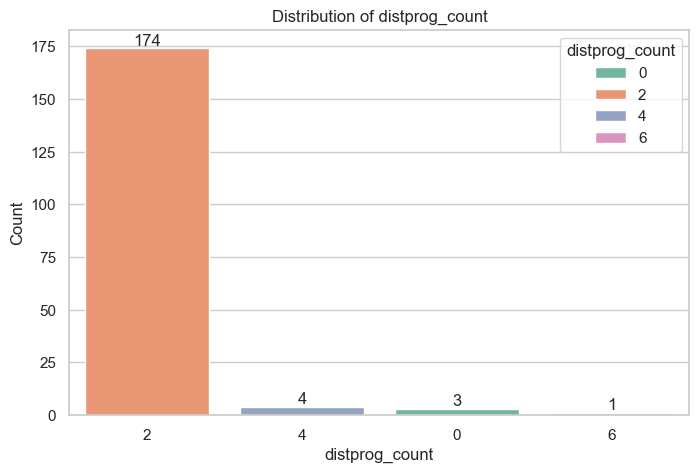

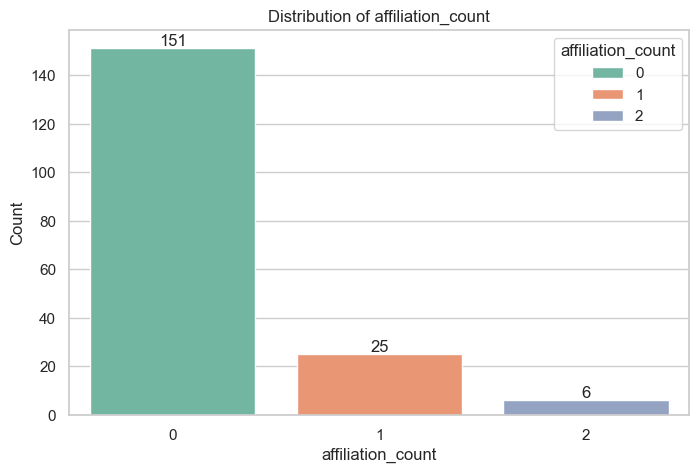

In [5]:
for_bar_cols = ['nature_code', 'distprog_count', 'affiliation_count'] # discrete numeric and categorical features
for col in for_bar_cols:
    plt.figure(figsize=(8, 5))
    ax = sns.countplot(data=df_schools, x=col, hue=col, order=df_schools[col].value_counts().index, palette='Set2')
    for container in ax.containers: # add the number labels on top of the bars
        ax.bar_label(container)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()


,count
sap_ind,15
top_psle_score,10
gifted_ind,9
autonomous_ind,3


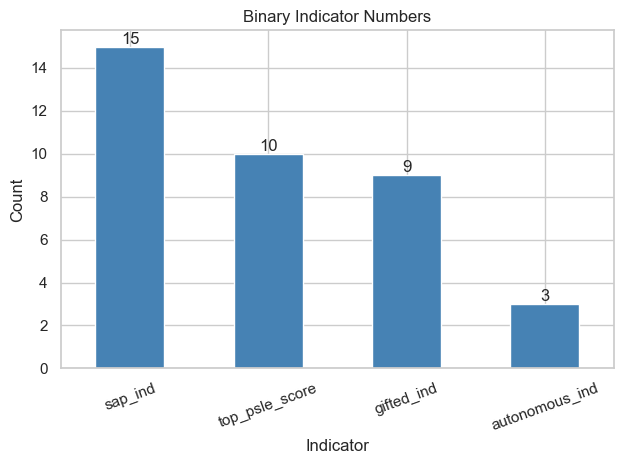

In [27]:
binary_cols = ['sap_ind', 'autonomous_ind', 'gifted_ind', 'top_psle_score'] # binary features
indicator_rates = df_schools[binary_cols].sum().sort_values(ascending=False)
display(indicator_rates.to_frame('count'))

ax = indicator_rates.plot(kind='bar', color='steelblue')
for container in ax.containers: # add the number labels on top of the bars
    ax.bar_label(container)
ax.set_title('Binary Indicator Numbers')
ax.set_xlabel('Indicator')
ax.set_ylabel('Count')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [7]:
# histograms for numeric features
for_hist_cols = [c for c in numeric_cols if c not in for_bar_cols and c not in binary_cols] # continuous numeric features
for_hist_cols #demand, subject count and ccas

['P1_demand',
 'P2A_demand',
 'P2B_demand',
 'P2C_demand',
 'P2CS_demand',
 'subject_count',
 'cca_clubs',
 'cca_others',
 'cca_sports',
 'cca_uniformed',
 'cca_arts']

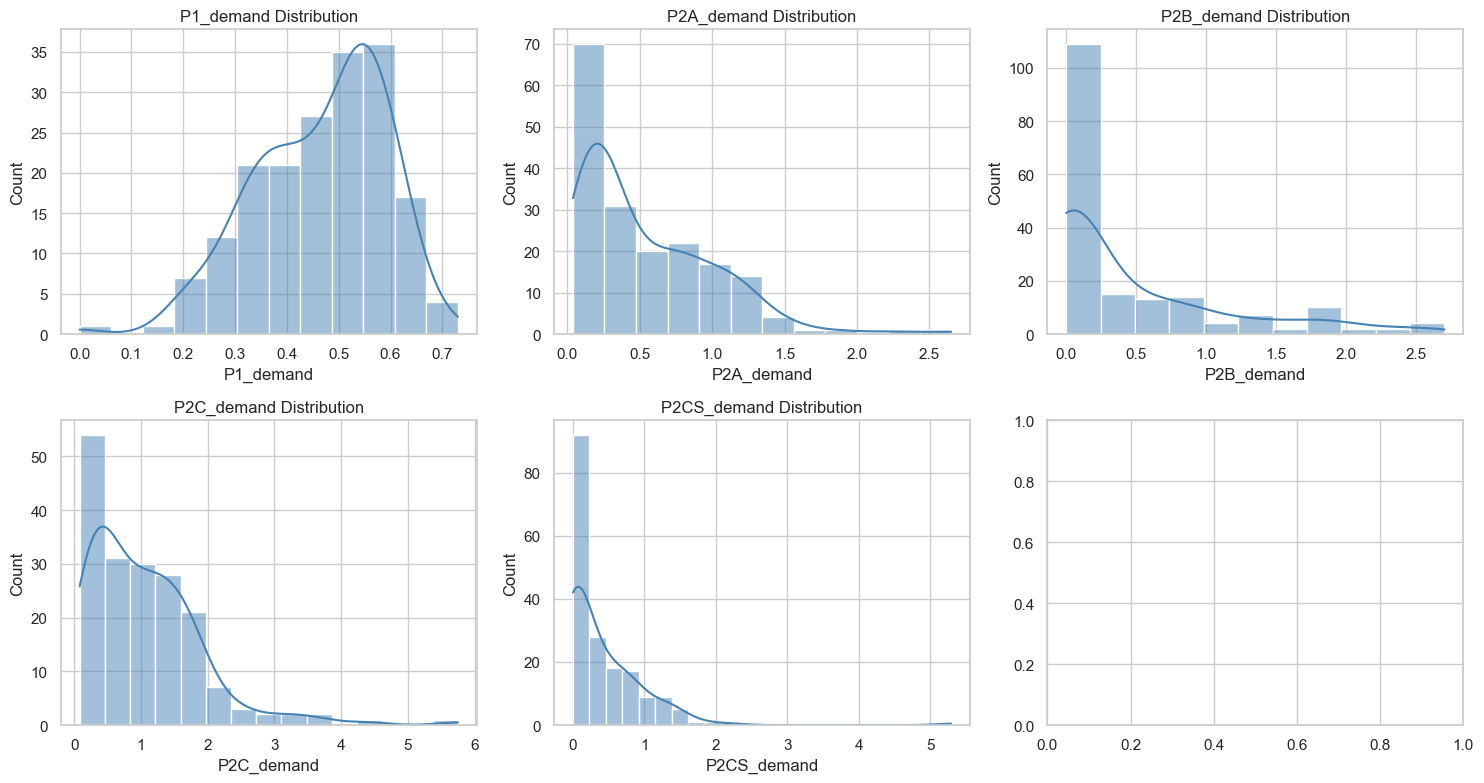

In [8]:
# demand histograms
demand_cols = ['P1_demand', 'P2A_demand', 'P2B_demand', 'P2C_demand', 'P2CS_demand']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(demand_cols):
    sns.histplot(df_schools[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'{col} Distribution')

plt.tight_layout()
plt.show()

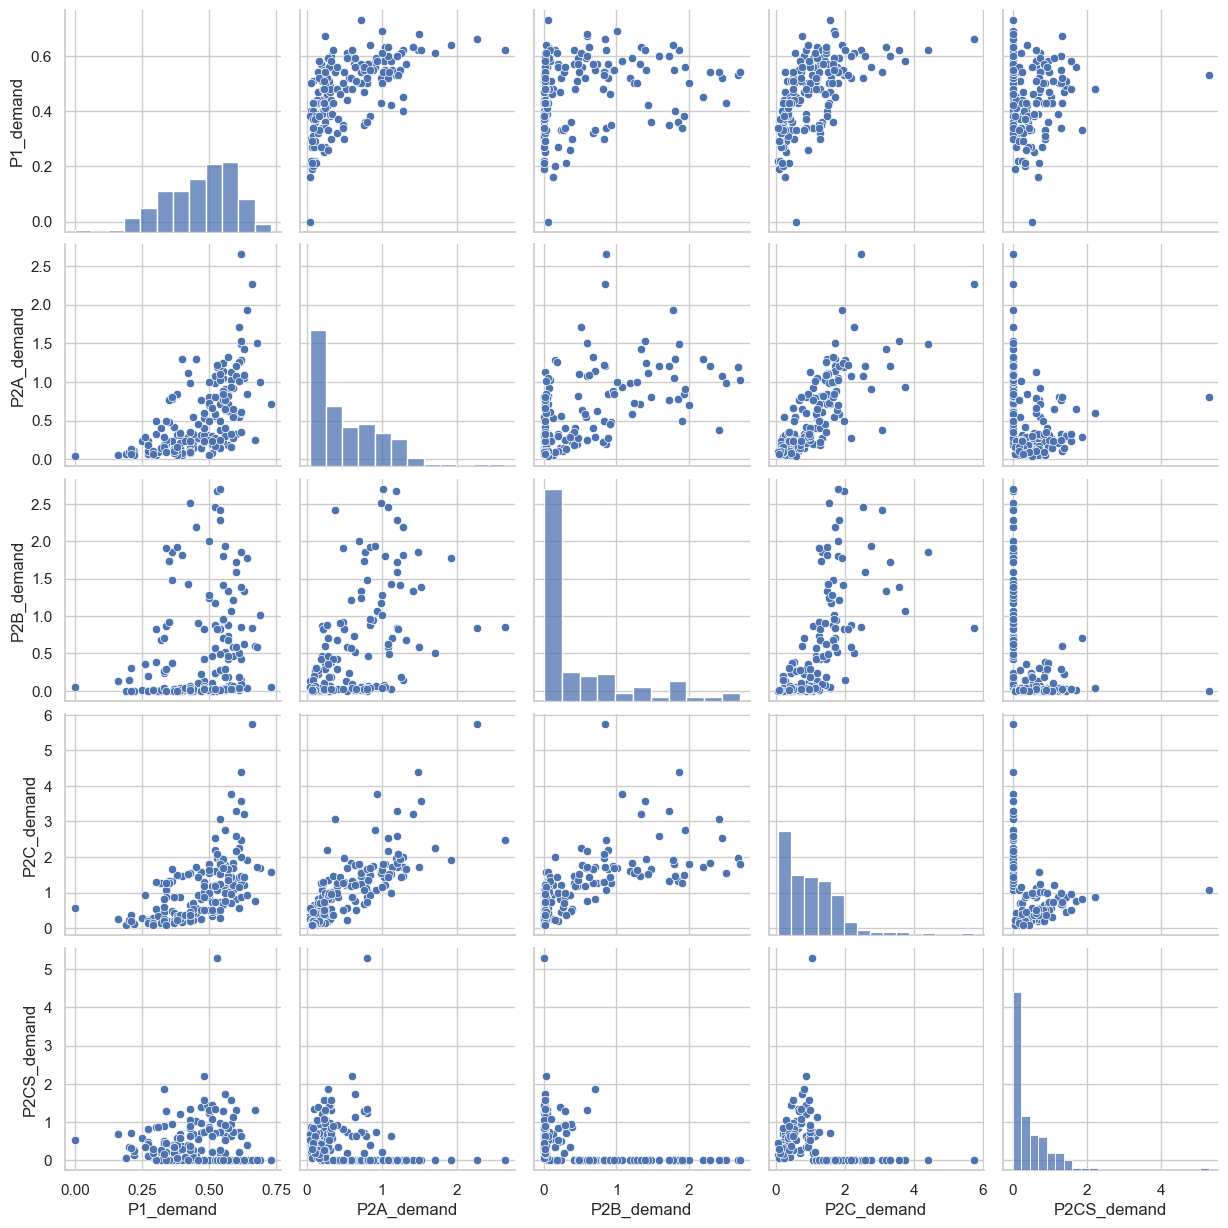

In [9]:
# pairplots
sns.pairplot(df_schools[demand_cols])

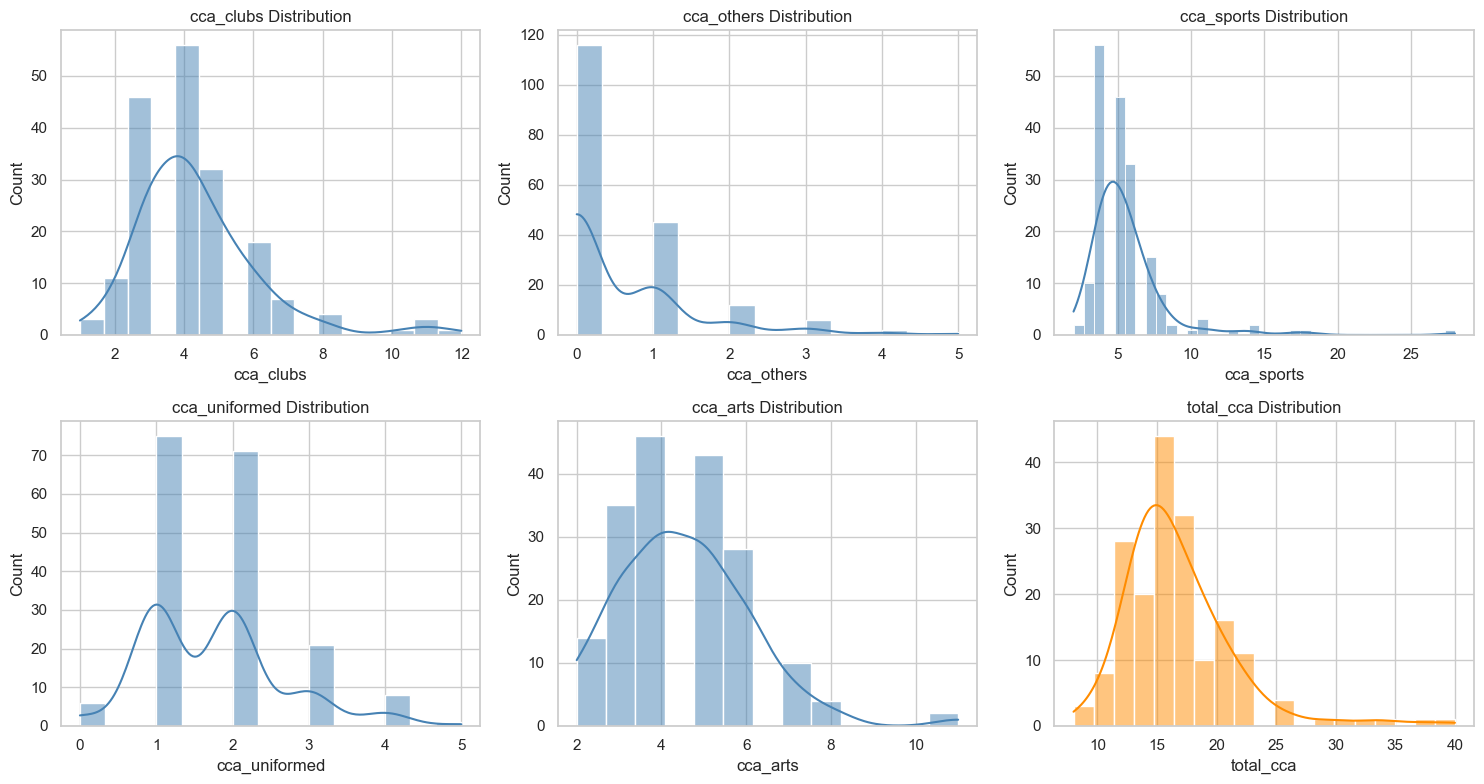

In [10]:
# cca histograms
cca_cols = ['cca_clubs',
 'cca_others',
 'cca_sports',
 'cca_uniformed',
 'cca_arts']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(cca_cols):
    sns.histplot(df_schools[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'{col} Distribution')

# sum up all ccas 
df_schools['total_cca'] = df_schools[cca_cols].sum(axis=1)
sns.histplot(df_schools['total_cca'], kde=True, ax=axes[-1], color='darkorange')
axes[-1].set_title('total_cca Distribution')

plt.tight_layout()
plt.show()

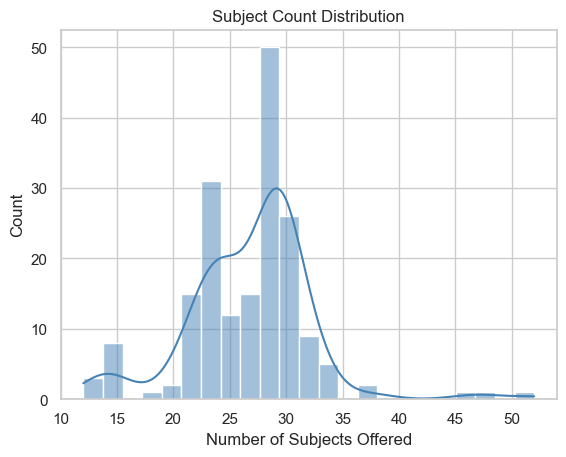

In [11]:
# histogram for subject count
sns.histplot(df_schools['subject_count'], kde=True, color='steelblue')
plt.title('Subject Count Distribution')
plt.xlabel('Number of Subjects Offered')
plt.ylabel('Count')
plt.show()

## EDA with tiers

### school scores and tiers

In [12]:
# pull data
df_school_tiers = pd.read_csv('../cleaned_datasets/schools_tiered.csv')
df_school_tiers['school_tier'].value_counts()

school_tier
Tier 4    68
Tier 3    60
Tier 2    31
Tier 1    23
Name: count, dtype: int64

In [13]:
# school scores 
df_school_tiers['school_score'].describe() # scores already standardised to 0-1

count    1.820000e+02
mean     3.904081e-17
std      1.002759e+00
min     -9.639681e-01
25%     -6.117885e-01
50%     -3.917686e-01
75%      1.541443e-01
max      4.199362e+00
Name: school_score, dtype: float64

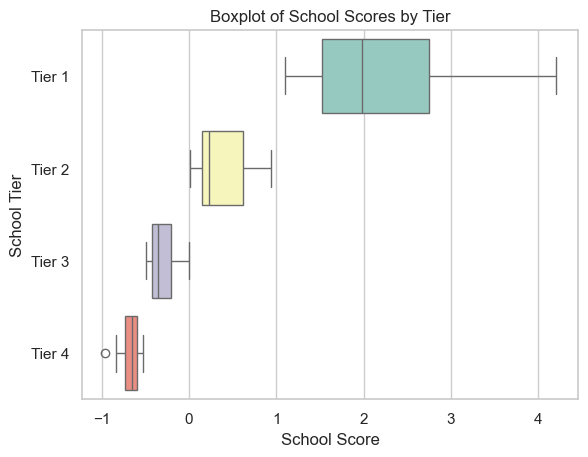

In [14]:
# boxplot of school scores by tier
sns.boxplot(data=df_school_tiers, y="school_tier", x="school_score", hue="school_tier", palette="Set3")
plt.title("Boxplot of School Scores by Tier")
plt.ylabel("School Tier")
plt.xlabel("School Score")
plt.show()

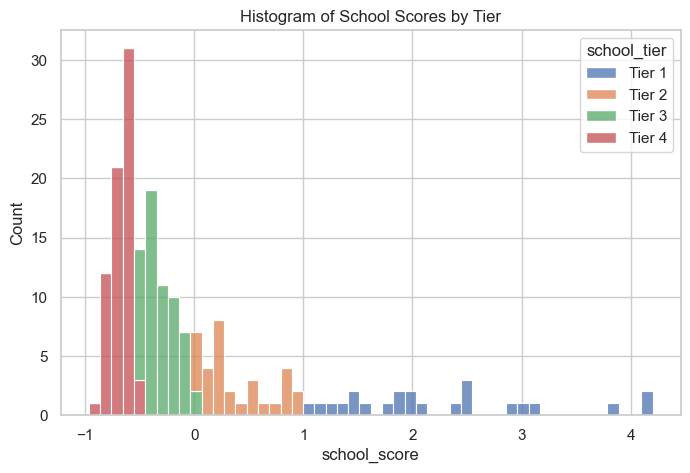

In [15]:
# see distribution of school_scores and school tiers 
plt.figure(figsize=(8, 5))
sns.histplot(data=df_school_tiers, x="school_score", hue="school_tier", multiple="stack", bins = 50)
plt.title("Histogram of School Scores by Tier")
plt.show()

### relations with other variables
school score derived from PC1

In [16]:
# find correlation of features with school scores
corr_with_score = df_school_tiers[numeric_cols + ['school_score']].corr()['school_score'].drop('school_score').sort_values(ascending=False)
print(corr_with_score) # corresponds with the PC1 feature loadings but not exactly the same since PC1 is a combination of features

P2B_demand           0.894641
sap_ind              0.742091
top_psle_score       0.651667
P2C_demand           0.648332
gifted_ind           0.623281
P2A_demand           0.610872
cca_clubs            0.479521
cca_sports           0.478761
autonomous_ind       0.455083
cca_uniformed        0.413771
affiliation_count    0.393485
cca_arts             0.352865
P1_demand            0.253048
distprog_count       0.085220
cca_others          -0.015924
subject_count       -0.127373
P2CS_demand         -0.363483
Name: school_score, dtype: float64


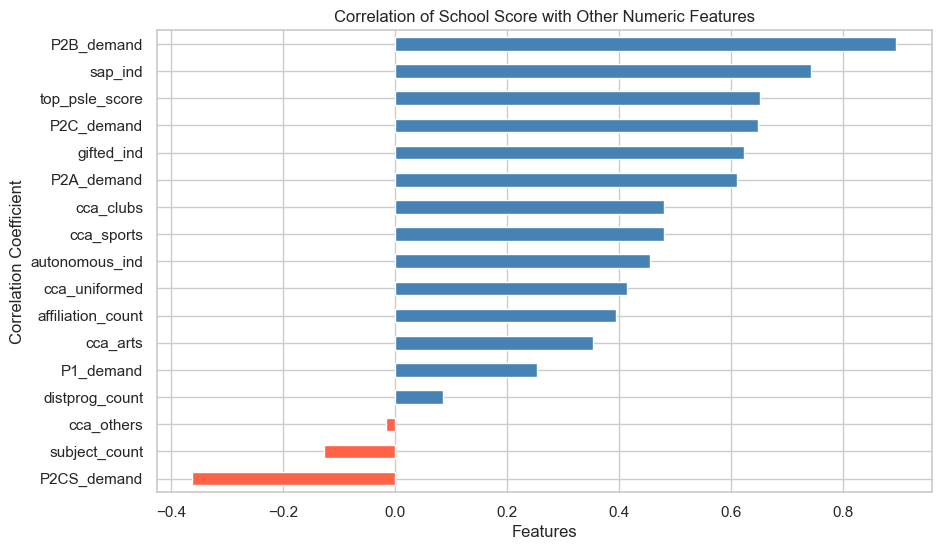

In [17]:
# Plot correlations as a bar chart
plt.figure(figsize=(10, 6))
corr_with_score = corr_with_score.sort_values(ascending=True)
colors = ['tomato' if x < 0 else 'steelblue' for x in corr_with_score]
corr_with_score.plot(kind='barh', color=colors)
plt.title('Correlation of School Score with Other Numeric Features')
plt.ylabel('Correlation Coefficient')
plt.xlabel('Features')
plt.show()


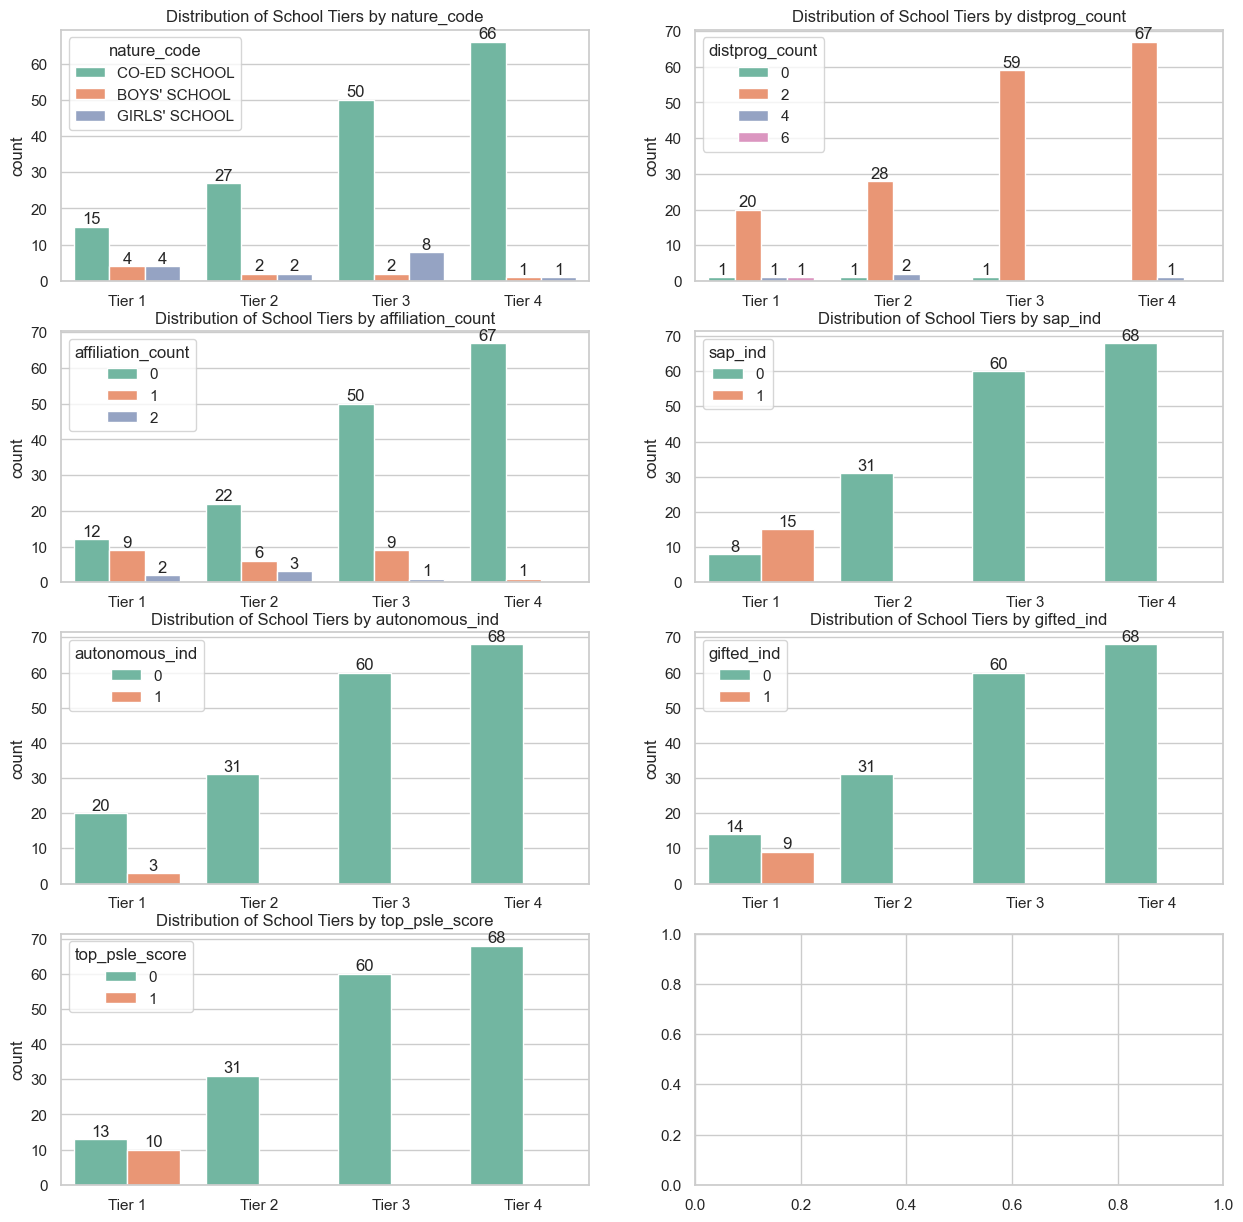

In [18]:
# Plot distribution of school tiers for all columns
# for barplots: for_bar_cols + binary_cols
# for histograms: for_hist_cols

fig, axes = plt.subplots(4, 2, figsize=(15, 15))
axes = axes.flatten()
for i, col in enumerate(for_bar_cols + binary_cols):
    ax = sns.countplot(data=df_school_tiers, x='school_tier', hue=col, palette='Set2', ax=axes[i])
    for container in ax.containers:
        ax.bar_label(container)
    axes[i].set_title(f'Distribution of School Tiers by {col}')
    axes[i].set_xlabel('')

# interesting all sap, gifted, top psle and autonomous schools are in tier 1

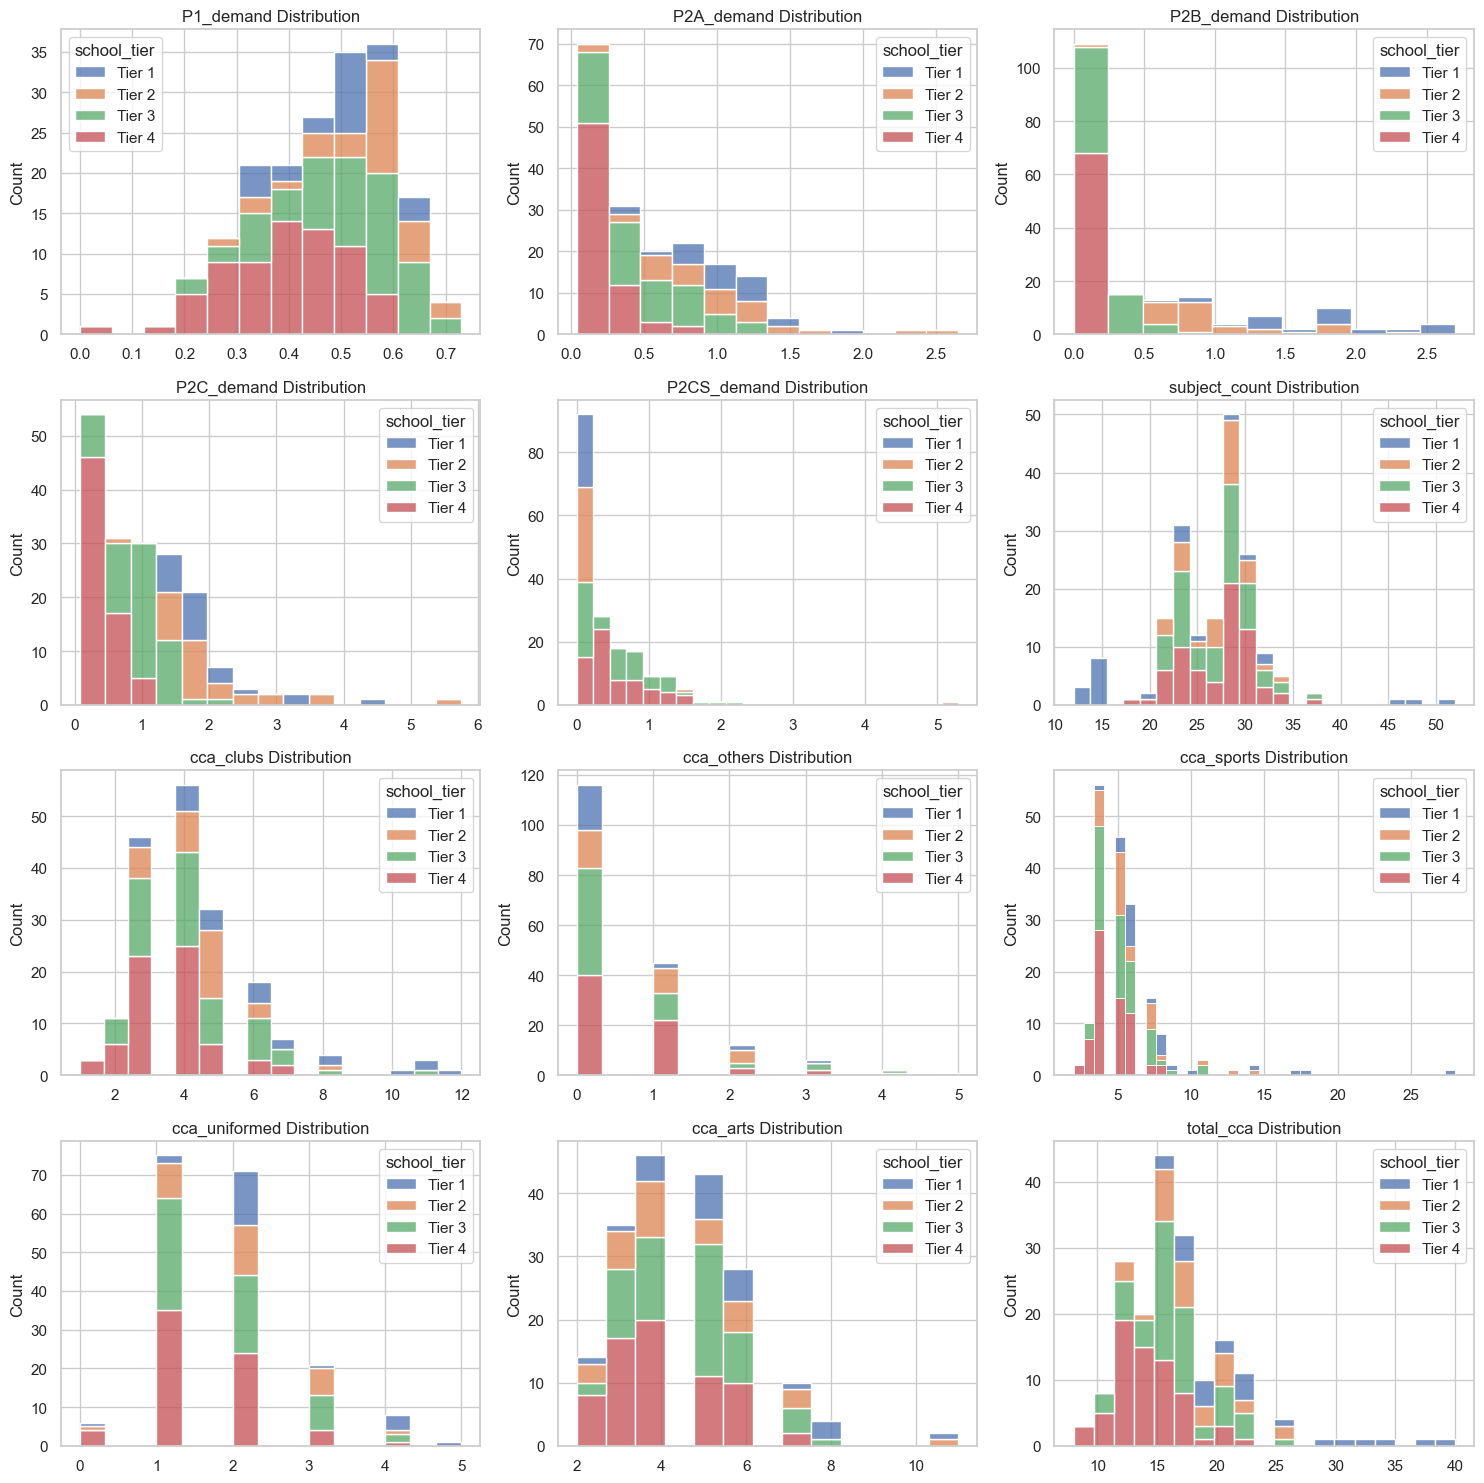

In [19]:
fig, axes = plt.subplots(4, 3, figsize=(15, 15))
axes = axes.flatten()
for i, col in enumerate(for_hist_cols):
    sns.histplot(df_school_tiers, x=col, ax=axes[i], hue='school_tier',multiple='stack')
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel('')

df_school_tiers['total_cca'] = df_school_tiers[cca_cols].sum(axis=1)
sns.histplot(df_school_tiers, x='total_cca', ax=axes[-1], hue='school_tier',multiple='stack')
axes[-1].set_title('total_cca Distribution')
axes[-1].set_xlabel('')

plt.tight_layout()
plt.show()
# dosent give much info tbh except that tier 1 and 2 schools have generally higher demand distribution for P2A/B/C. 
# and until P2CS there are no more slots so the demand is 0 
# also tier 1 schools generally have more ccas

## add school geographical locations 

In [20]:
# to add the school locations longitude and lattitude, then to plot the locations 

# get station coordinates from onemap API
def get_onemap_location(location_name):
    endpoint = "https://www.onemap.gov.sg/api/common/elastic/search"

    res = requests.get(
        endpoint,
        params={
            "searchVal": location_name,
            "returnGeom": "Y",
            "getAddrDetails": "Y",
            "pageNum": "1",
        },
        timeout=15,
    ).json()
    results = res.get("results", None)
    if isinstance(results, list):
        for result in results:
            if "LATITUDE" in result and "LONGITUDE" in result:
                return float(result["LATITUDE"]), float(result["LONGITUDE"])
    return None

# initialise location dictionary
schools = {
        school: {
            "lat": None,
            "lon": None,
        }
        for school in df_school_tiers['school_name']
    }

# find location from onemap
for school in df_school_tiers['school_name']:
    try:
        coordinates = get_onemap_location(school)
        if coordinates is None:
            print(school) # check which schools are unfindable 
        if coordinates[0] is not None and coordinates[1] is not None:
            schools[school]["lat"] = coordinates[0]
            schools[school]["lon"] = coordinates[1]
        time.sleep(0.1)
    except Exception as e:
        _ = e

In [21]:
sch_loc = pd.DataFrame(schools).T.reset_index()
sch_loc = sch_loc.rename(columns={"index": "school_name"})
schools_locations_df = pd.merge(df_school_tiers, sch_loc, on=["school_name", "lat", "lon"], how="left")


In [22]:
schools_locations_df

,school_name,address,postal_code,nature_code,sap_ind,autonomous_ind,gifted_ind,P1_demand,P2A_demand,P2B_demand,...,cca_sports,cca_uniformed,cca_arts,affiliation_count,top_psle_score,school_score,school_tier,total_cca,lat,lon
0,NANYANG PRIMARY SCHOOL,52 KING'S ROAD,268097,CO-ED SCHOOL,1,0,1,0.54,1.21,2.29,...,8,4,8,1,1,4.199362,Tier 1,30,1.320847,103.807750
1,CATHOLIC HIGH SCHOOL,9 BISHAN STREET 22,579767,BOYS' SCHOOL,1,1,1,0.40,1.29,1.81,...,17,5,8,1,1,4.148977,Tier 1,33,1.354525,103.844901
2,CHIJ ST. NICHOLAS GIRLS' SCHOOL,501 ANG MO KIO STREET 13,569405,GIRLS' SCHOOL,1,1,0,0.45,1.29,2.19,...,8,4,11,1,1,3.871867,Tier 1,34,1.373477,103.834253
3,TAO NAN SCHOOL,49 MARINE CRESCENT,449761,CO-ED SCHOOL,1,0,1,0.54,1.02,2.70,...,8,4,6,0,0,3.066495,Tier 1,22,1.294332,103.849026
4,NAN HUA PRIMARY SCHOOL,30 Jalan Lempeng,128806,CO-ED SCHOOL,1,0,1,0.62,1.49,1.86,...,6,2,4,0,0,2.960970,Tier 1,20,1.319202,103.761095
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177,EDGEFIELD PRIMARY SCHOOL,41 EDGEFIELD PLAINS,828869,CO-ED SCHOOL,0,0,0,0.40,0.08,0.00,...,4,1,3,0,0,-0.815958,Tier 4,11,1.400091,103.907848
178,ZHONGHUA PRIMARY SCHOOL,12 SERANGOON AVENUE 4,556095,CO-ED SCHOOL,0,0,0,0.29,0.07,0.01,...,3,1,4,0,0,-0.816120,Tier 4,11,1.360203,103.869762
179,PIONEER PRIMARY SCHOOL,80 TENGAH GARDEN AVENUE,699915,CO-ED SCHOOL,0,0,0,0.00,0.04,0.05,...,4,2,2,0,0,-0.830745,Tier 4,13,1.339023,103.687770
180,BENDEMEER PRIMARY SCHOOL,91 BENDEMEER ROAD,339948,CO-ED SCHOOL,0,0,0,0.33,0.17,0.01,...,6,0,5,0,0,-0.837486,Tier 4,13,1.321813,103.865404


In [23]:
# check if there are any None locations
schools_locations_df[schools_locations_df['lat'].isnull()]

,school_name,address,postal_code,nature_code,sap_ind,autonomous_ind,gifted_ind,P1_demand,P2A_demand,P2B_demand,...,cca_sports,cca_uniformed,cca_arts,affiliation_count,top_psle_score,school_score,school_tier,total_cca,lat,lon


In [24]:
# update the csv for school tiers with locations
schools_locations_df.to_csv('../cleaned_datasets/schools_tiered.csv', index=False)

In [25]:
# Folium map of all schools 
my_map = folium.Map(location = (1.359394, 103.814301), zoom_start = 12)
marker_cluster = MarkerCluster().add_to(my_map)

for index, row in schools_locations_df.iterrows():
    folium.Marker(
        location=[row['lat'], row['lon']],
        popup=row['school_name'], # Optional: add a popup with a name or info
    ).add_to(marker_cluster)
my_map

In [30]:
# Folium map of Tier 1 schools 
my_map = folium.Map(location = (1.359394, 103.814301), zoom_start = 12)

for index, row in schools_locations_df[schools_locations_df['school_tier'] == "Tier 1"].iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=2,
        color="black",
        fill=True,
        fill_color="black",
        popup="Circle Marker"
    ).add_to(my_map)

    # add 1km raius
    folium.Circle(
        radius=1000,
        location=[row['lat'], row['lon']],
        color = "blue", 
        weight = 1,
        fill=True,
        fill_color="blue",
        fill_opacity=0.2,
        tooltip="1km Radius"
    ).add_to(my_map)

    # add 2km Radius
    folium.Circle(
        radius=2000,
        location=[row['lat'], row['lon']],
        color = "red", 
        weight = 1,
        fill=True,
        fill_color="red",
        fill_opacity=0.1,
        tooltip="2km Radius"
)   .add_to(my_map)

my_map